# (노트) 깁스샘플링
> 미완성

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- categories: [통계계산]

### About this doc

`-` 전북대 강의노트

### 예제1

`-` 주사위 2개를 던져서 확률변수 $X$와 $Y$를 아래와 같이 정의하자. 
- $X$: 첫번째 주사위의 던졌을때 나오는 숫자 ($X=1,2,3,4,5,6$)
- $Y$: 두 주사위의 합 ($Y=2,3,\dots,12$)

`-` $X,Y$의 확률질량함수는 아래와 같다. 

|$x$|1|2|3|4|5|6|
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
|$p(x)$|1/6|1/6|1/6|1/6|1/6|1/6|

|$y$|2|3|4|5|6|7|8|9|10|11|12|
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
|$p(x)$|1/36|2/36|3/36|4/36|5/36|6/36|5/36|4/36|3/36|2/36|1/36|

`-` 확률변수 $X$와 $Y$를 1000개씩 만들어보자. 아래와 같이 쉽게 할 수 있다. 

In [5]:
X=sample(1:6,size=10000,replace=T)
print(head(X))

[1] 4 2 4 2 4 6


In [6]:
Y=X+sample(1:6,size=10000,replace=T)
print(head(Y))

[1]  7  7  5  3  8 12


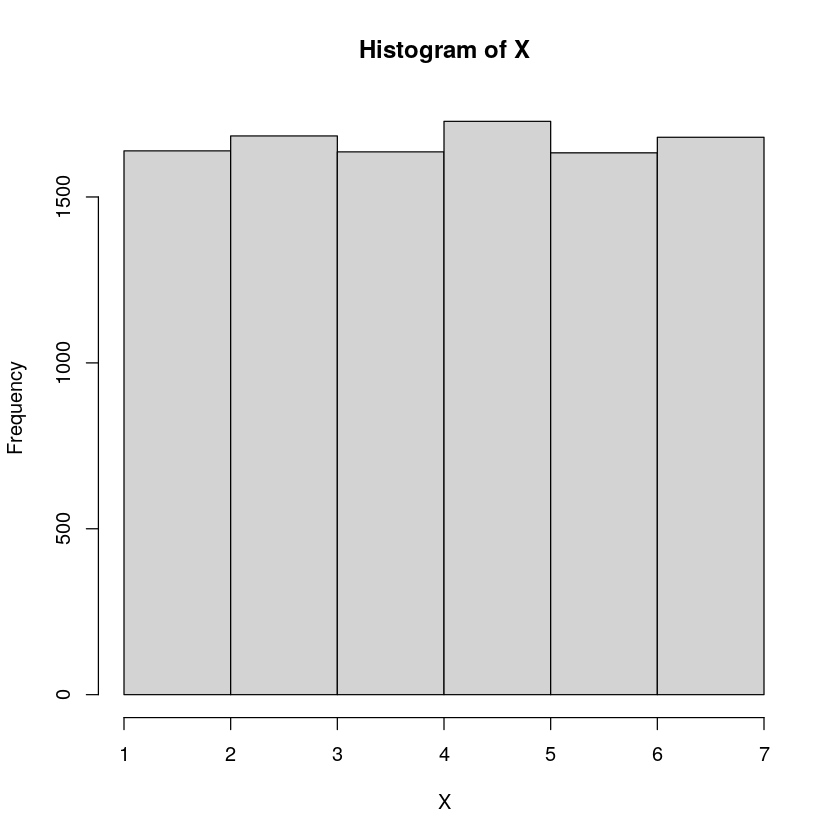

In [7]:
hist(X,1:7,right=F)

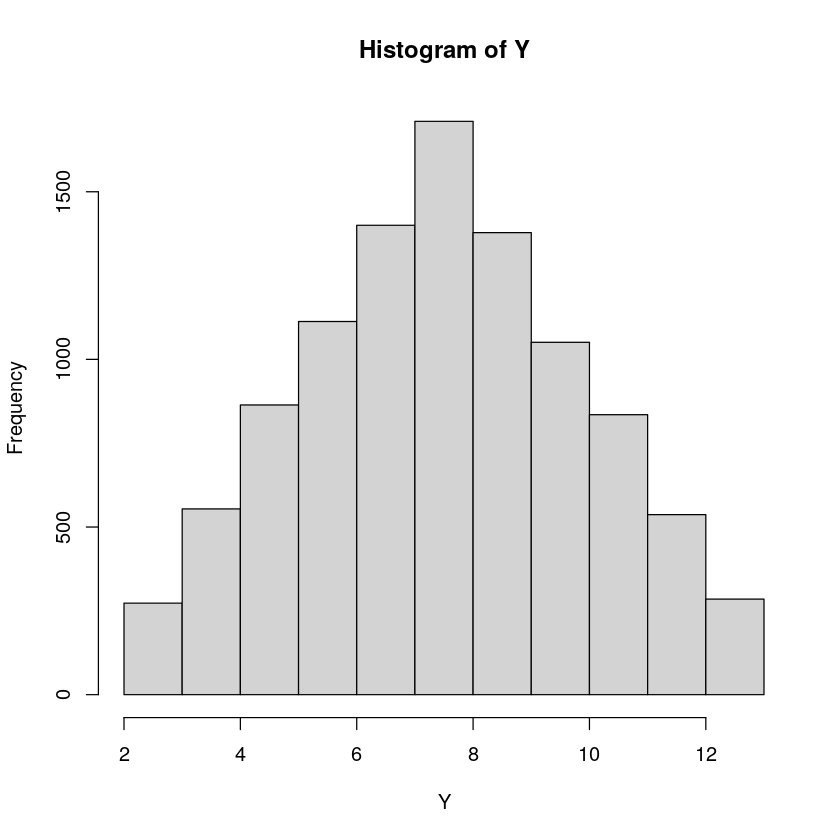

In [8]:
hist(Y,2:13,right=F)

`-` 그런데 잘 생각해보니까 $X$를 이미 얻었다면 $Y$는 $X$를 이용하여 쉽게 만들 수 있을 것 같다. 

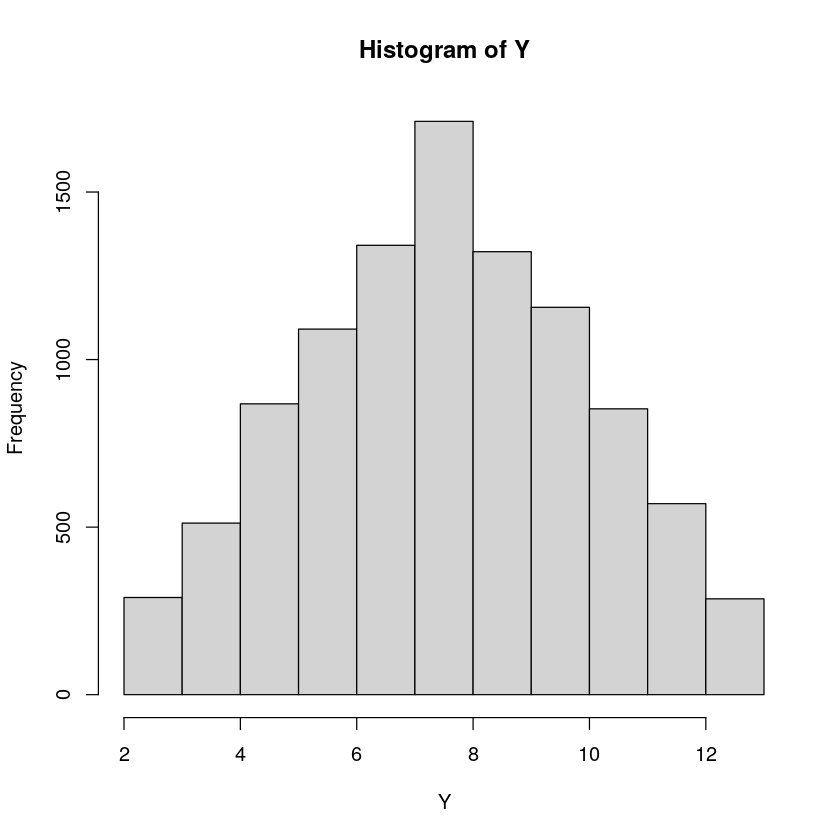

In [9]:
Y=X+sample(1:6,size=10000,replace=T)
hist(Y,breaks=2:13,right=F)

`-` 그렇다면 $Y=y$를 알고 있을때 $X$를 쉽게 얻을 수 있을까? 


- $P(X|Y=y)=?$

|y|X|
|:-:|:-:|
|2|1|
|3|1,2| 
|4|1,2,3| 
|5|1,2,3,4| 
|6|1,2,3,4,5| 
|7|1,2,3,4,5,6| 
|8|2,3,4,5,6| 
|9|3,4,5,6| 
|10|4,5,6| 
|11|5,6| 
|12|6| 

`-` 알 수 있다. 수식으로 요약하면 
- $y\leq 7$ 일 경우: $x$는 $1 \sim (y-1)$ 사이의 숫자를 랜덤으로 뽑는다. 
- $y>7$ 일 경우: $x$는 $(y-6) \sim 6$ 사이의 숫자를 랜덤으로 뽑는다. 

In [42]:
fx_giveny <-function(y){
    if(y==12){
        x<-6
    } else if(y>7){
      x<-sample((y-6):6,size=1)  
    } else {
      x<-sample(1:(y-1),size=1)
    }
    x
}

`-` 그렇다면 아래와 같이 샘플링 할 수도 있지 않을까? 

($random \sim$ 주사위) 

- $x_1$을 뽑는다. $x_1=random$

- $y_1$은 $x_1$을 이용하여 추출한다. 즉 $y_1=x_1+random$

- $x_2$는 $y_1$을 이용하여 추출한다 즉 $x_2 \sim f(x_2|y_1)$

- $y_2$는 다시 $x_2$를 이용하여 추출한다. 즉 $y_2=x_2+random$

In [43]:
set.seed(3)
x<-c()
y<-c()
x[1]<-sample(1:6,size=1)
y[1]<-x[1]+sample(1:6,size=1)

In [44]:
print(x)

[1] 5


In [45]:
print(y)

[1] 7


In [46]:
x[2]<-fx_giveny(y[1])
y[2]<-x[2]+sample(1:6,size=1)

In [47]:
print(x)

[1] 5 4


In [48]:
print(y)

[1] 7 8


In [49]:
x[3]<-fx_giveny(y[2])
y[3]<-x[3]+sample(1:6,size=1)

In [50]:
print(x)

[1] 5 4 3


In [51]:
print(y)

[1] 7 8 6


In [52]:
y[3]

[1] 6

In [53]:
x[4]<-fx_giveny(y[3])

In [54]:
print(x)

[1] 5 4 3 4


`-` 이렇게 뽑아서 되는건가 싶은 느낌이 있다. 

`-` 많이 뽑아서 그려보자.

In [55]:
x<-c()
y<-c()
x[1]<-sample(1:6,size=1)
for(i in 1:500000){ 
    y[i]<-x[i]+sample(1:6,size=1)
    x[i+1]<-fx_giveny(y[i])
}

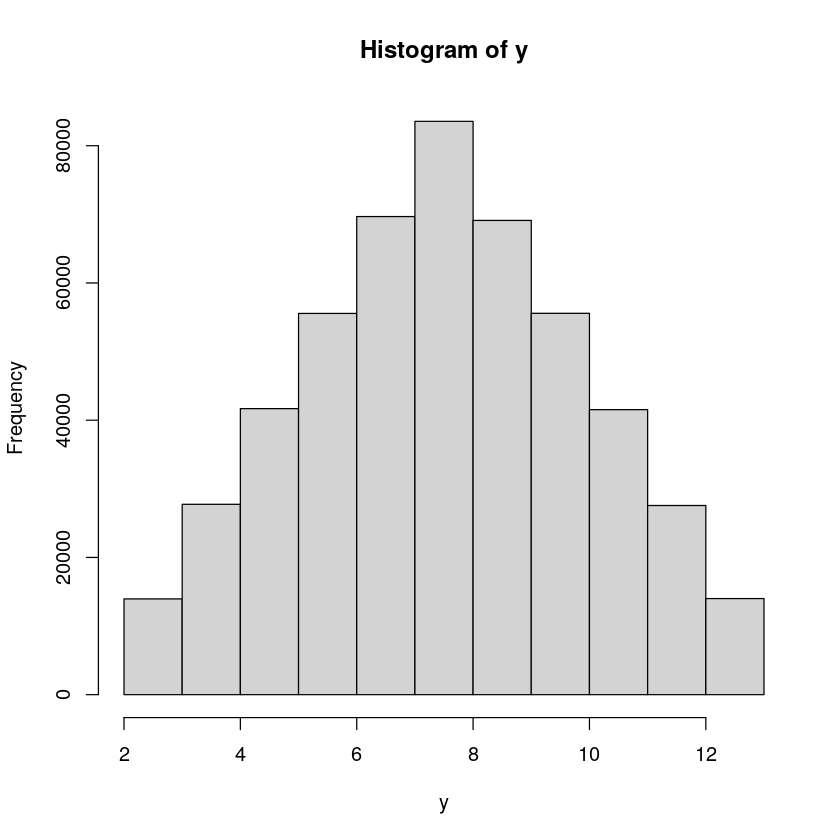

In [56]:
hist(y,breaks=2:13,right=F)

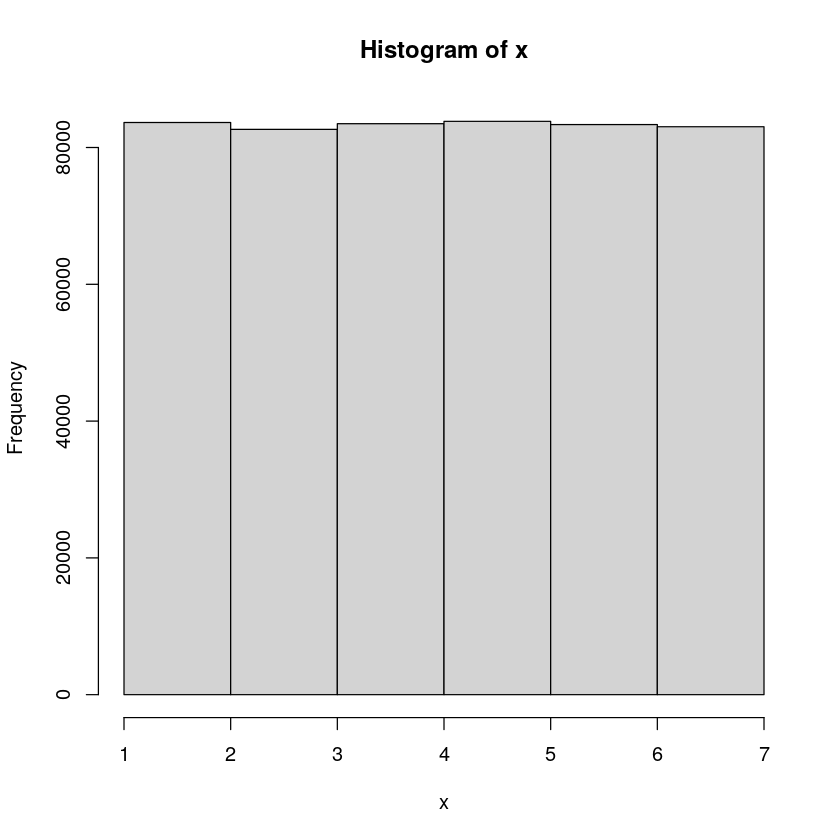

In [57]:
hist(x,breaks=1:7,right=F)

### 왜 이것이 가능한가? (일반적인 증명은 생략)

`-` $(X,Y)$의 확률질량함수를 $f(x,y)$라고 하자. 

`-` detailed balance condition을 만족하는지 따지자. 

`-` 우선 $X$만 따져보자.. 

`-` $p(x_{t+1}|x_t)f(x_t) = p(x_t|x_{t+1})f(x_{t+1})$ 임을 보이면 된다. 

`-` 그런데 사실 일반적으로 보이는것이 조금 까다롭다. 그래서 이 예제에 한정해서 성립하는지만 체크해보자. 

`-` detailed balance condition의 원래 버전은 아래와 같았다. 

$$transition(x_t \to x_{t+1}) \pi(x_t) = transition(x_{t+1} \to x_{t}) \pi(x_{t+1})$$

우리의 예제로 바꾸면 아래를 보이면 된다. 

- $transition(1 \to 1) \pi(1) = transition(1 \to 1) \pi(1)$
- $transition(1 \to 2) \pi(1) = transition(2 \to 1) \pi(2)$
- ... 
- $transition(1 \to 6) \pi(1) = transition(6 \to 1) \pi(6)$
- ... 
- $transition(6 \to 6) \pi(6) = transition(6 \to 6) \pi(6)$

노가다를 활용하면 성립함을 알 수 있다. $transition(1\to 1)=\frac{1}{6}$ 이고, $transition(6\to 6)=\frac{1}{36}$이다. 

`-` detailed balance condition을 만족하므로 $\{X_t\}$는 stationary process이다. 

`-` 노가다를 활용하여 $\{Y_t\}$ 역시 stationary process임을 알 수 있다. 

`-` conditional은 이미 알고 있다고 가정하였고, marginal을 시뮬레이션할 수 있으므로 joint를 시뮬레이션으로 생성할 수 있다. (다 알 수 있다)

### 깁스샘플링 (알고리즘) 

#### 2차원 

`-` $X_0=x_0$를 선택 

`-` $t=1,2,\dots$에 대하여 아래를 반복하면서 생성한다. 
 - $Y_t \sim f_{Y|X}(\cdot |x_{t-1})$
 - $X_t \sim f_{X|Y}(\cdot |y_t)$ 

#### 다차원 

`-` ${\bf x}^{(t)}=(x_1^{(t)},\dots,x_p^{(t)})$ 가 주어졌을때 아래를 반복 

- $X_1^{(t+1)} \sim f_1(x_1|x_2^{(t)},\dots,x_p^{(t)})$ 
- $X_2^{(t+1)} \sim f_2(x_1|x_1^{(t+1)},x_3^{(t)},\dots,x_p^{(t)})$ 
- ... 
- $X_p^{(t+1)} \sim f_p(x_1|x_1^{(t+1)},\dots,x_{p-1}^{(t)})$ 

느낌: 나 빼고 $p-1$의 값이 다 뽑혔으면 그걸 바탕으로 나도 1차원 랜덤변수 만들 수 있음. 

`-` 첫 시작은 누가?... 